# Philadelphia Synthetic Trajectory Data - Analysis

This notebook analyzes synthetic data for 200 users in Philadelphia generated with the traj_gen.py module of the nomad library. For reference, we also examine the ground-truth travel diaries of individuals indicating the dwells and POIs of each segment of their trajectories. We also report on the completeness of the generated data, which varies due to induced sparsity and irregularity in the sampling of ping times.  

## Data Sources
- **Device-level trajectories**: Individual location pings (x, y coordinates)
- **Stop tables**: Ground truth stops derived from the trajectories
- **POI data**: OpenStreetMap points of interest used for simulation

In [1]:
!pip install git+https://github.com/Watts-Lab/nomad.git

  Cloning https://github.com/Watts-Lab/nomad.git to /tmp/pip-req-build-v6crp7ww
  Running command git clone --filter=blob:none --quiet https://github.com/Watts-Lab/nomad.git /tmp/pip-req-build-v6crp7ww
  Resolved https://github.com/Watts-Lab/nomad.git to commit 7b4cbc442ba65c848a747a2e1fdea6fa2d23e22f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!pip install contextily geopandas

In [3]:
import nomad.io.base as loader
import nomad.filters as filters
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import nomad.stop_detection.viz as viz
from shapely import wkt

## 1. Data Loading

We use `nomad.io.base.from_file()` to load trajectory and stop data from S3. 
This function handles Parquet datasets and automatically sorts by user_id and timestamp.

In [47]:
DEVICE_LEVEL_PATH = "s3://catalog-onspatial/geolife_plus_phl/diaries/"
STOP_TABLES_PATH = "s3://catalog-onspatial/geolife_plus_phl/device-level/trajectories_sparse/"
POI_DATA_PATH = "s3://catalog-onspatial/geolife_plus_phl/poi_table/poi_table_visited.parquet"

device_df = loader.from_file(DEVICE_LEVEL_PATH, format="parquet")
stop_df = loader.from_file(STOP_TABLES_PATH, format="parquet")
poi_df = pd.read_parquet(POI_DATA_PATH)
poi_df['geometry'] = poi_df["geometry"].apply(wkt.loads)
poi_gdf = gpd.GeoDataFrame(poi_df, geometry = "geometry", crs = "EPSG:32618")


print(f"Loaded {len(device_df):,} pings for {device_df['user_id'].nunique()} users")
print(f"Loaded {len(stop_df):,} stops")
print(f"Date range: {device_df['date'].min()} to {device_df['date'].max()}")

Loaded 35,361 pings for 200 users
Loaded 228,000 stops
Date range: 2025-07-01 to 2025-07-30


## 2. POI Visualization

OpenStreetMap POIs used to generate the synthetic trajectories.

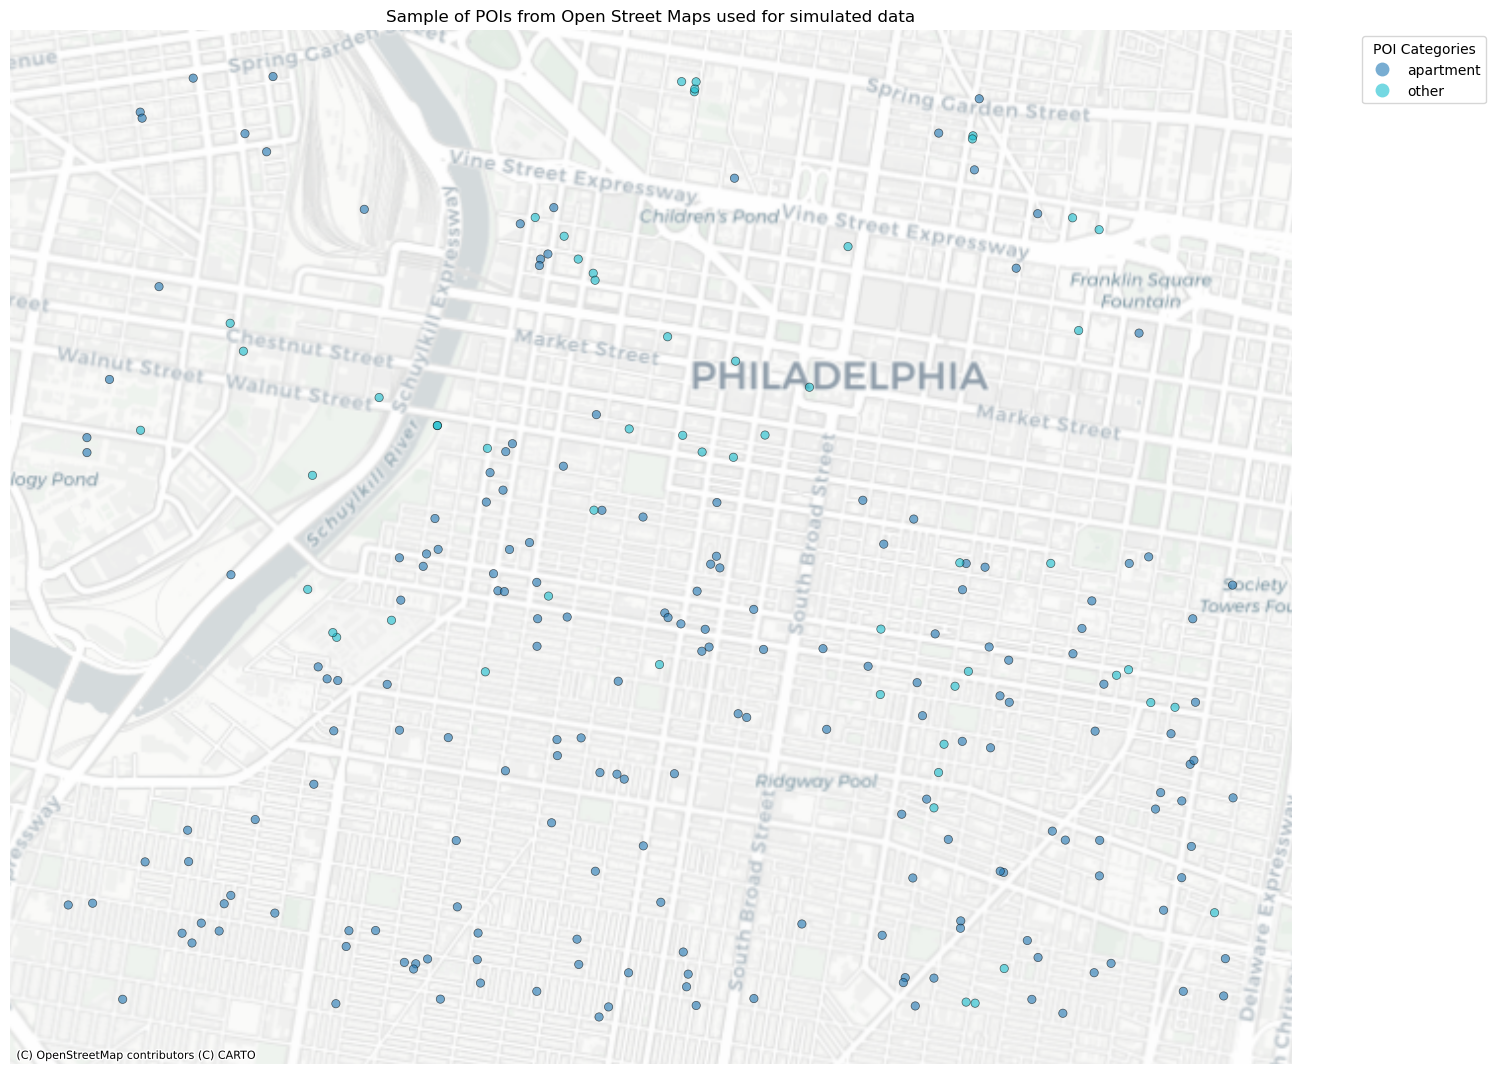

In [48]:
fig, ax = plt.subplots(figsize=(15, 15))
counts = poi_gdf['venue_type'].value_counts()
keep_cats = counts[counts > 50].index.tolist()
poi_gdf['plot_cat'] = poi_gdf['venue_type'].apply(lambda x: x if x in keep_cats else 'other')
poi_gdf.plot(
    column='plot_cat',
    ax=ax, 
    categorical=True,
    legend=True,
    cmap='tab10',
    alpha=0.6, 
    edgecolor='black', 
    linewidth=0.5, 
    legend_kwds={'bbox_to_anchor': (1.05, 1), 'loc': 'upper left', 'title': 'POI Categories'}
)
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs="EPSG:32618")
ax.set_title("Sample of POIs from Open Street Maps used for simulated data")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Trajectory Visualization

We visualize trajectories for 3 sample users on a single day. 
- **Black dots**: Individual location pings
- **Red circles**: Ground truth stops 

In [49]:
stop_df_day

,user_id,x,y,start_time,end_time,venue_id,timestamp,duration,date
0,0,486526.011015,4.423422e+06,2025-07-01 07:15:00,2025-07-01 12:00:00,308,1751354100,17100,2025-07-01
1,0,486895.421937,4.423118e+06,2025-07-01 12:05:00,2025-07-01 12:25:00,353,1751371500,1200,2025-07-01
2,0,486526.011015,4.423422e+06,2025-07-01 12:30:00,2025-07-01 13:50:00,308,1751373000,4800,2025-07-01
3,0,485057.585909,4.420443e+06,2025-07-01 13:55:00,2025-07-01 14:00:00,1,1751378100,300,2025-07-01
4,0,486398.420451,4.421061e+06,2025-07-01 14:05:00,2025-07-01 15:20:00,352,1751378700,4500,2025-07-01
...,...,...,...,...,...,...,...,...,...
35117,99,486766.143104,4.423133e+06,2025-07-01 18:25:00,2025-07-01 18:30:00,136,1751394300,300,2025-07-01
35118,99,484951.924800,4.421715e+06,2025-07-01 18:40:00,2025-07-01 20:40:00,351,1751395200,7200,2025-07-01
35119,99,486766.143104,4.423133e+06,2025-07-01 20:50:00,2025-07-01 20:55:00,136,1751403000,300,2025-07-01
35120,99,486398.420451,4.421061e+06,2025-07-01 21:00:00,2025-07-01 23:15:00,352,1751403600,8100,2025-07-01


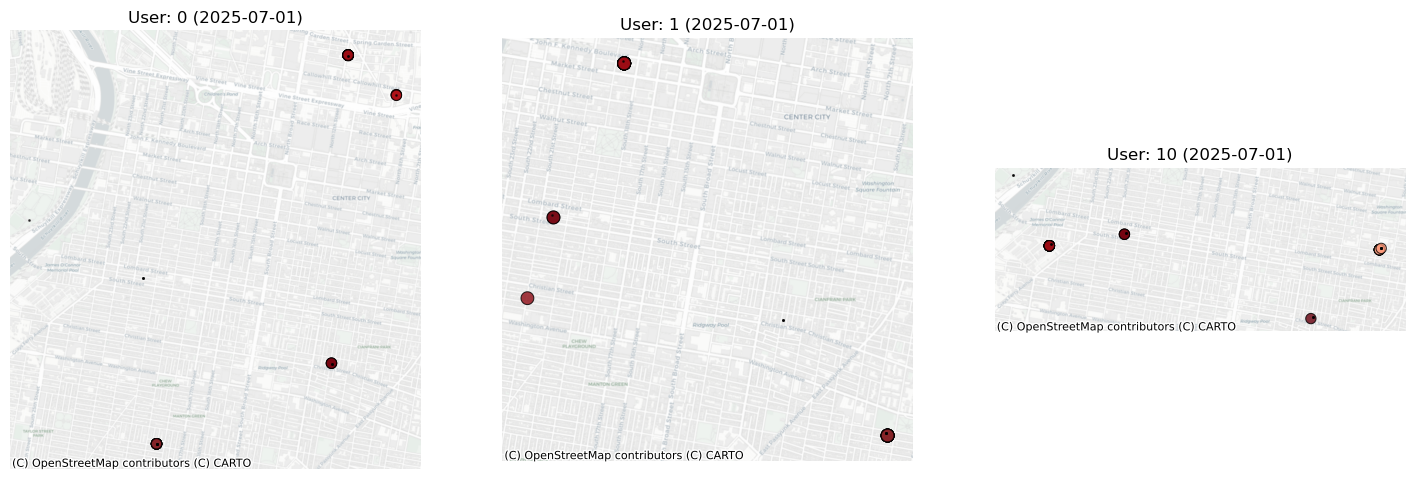

In [50]:
sample_date = device_df['date'].value_counts().index[0]
device_df_day = device_df[device_df['date'] == sample_date]
stop_df_day = stop_df[stop_df['date'] == sample_date]

selected_users = device_df_day.user_id.unique()[:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, user_id in enumerate(selected_users):
    ax = axes[i]
    
    user_pings = device_df_day.query("user_id == @user_id")
    user_stops = stop_df_day.query("(user_id == @user_id) and (x != None)").copy()
    user_stops['cluster'] = range(1, len(user_stops) + 1)
    
    viz.plot_pings(user_pings, ax, color='black', s=1, alpha=0.6)
    viz.plot_stops(user_stops, ax, radius=40, cmap='Reds', traj_cols={'x': 'x', 'y': 'y'})
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, crs="EPSG:32618")
    ax.set_title(f"User: {user_id} ({sample_date})")
    ax.set_axis_off()

#plt.tight_layout()
plt.show()

## 4. Data Completeness Analysis

We assess data completeness at two temporal resolutions:
- **Hourly**: Proportion of hours in which each user has at least one ping
- **Daily**: Proportion of days in which each user has at least one ping

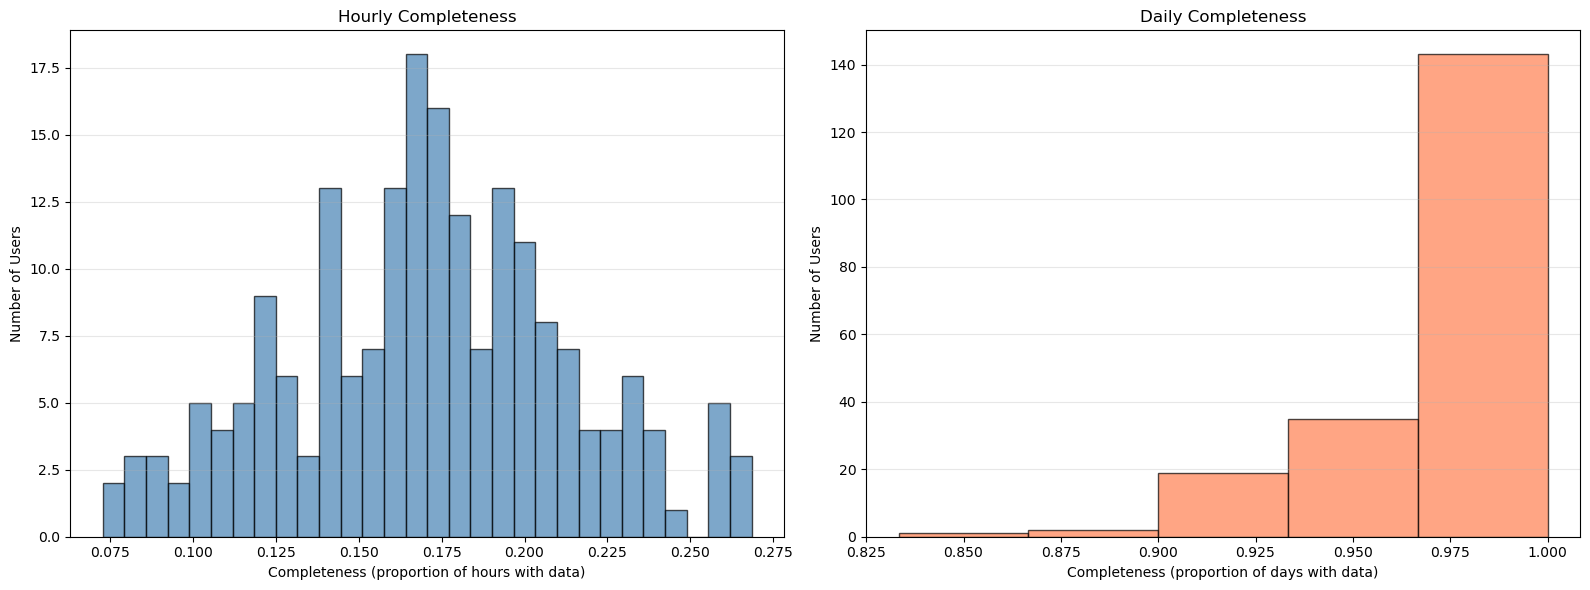

Completeness Statistics:
  Hourly  - Mean: 0.170, Median: 0.171
  Daily   - Mean: 0.966, Median: 0.967


In [51]:
comp_hourly = filters.completeness(device_df, periods=1, freq='h', user_id='user_id', timestamp='timestamp')
comp_daily = filters.completeness(device_df, periods=1, freq='d', user_id='user_id', timestamp='timestamp')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Hourly: reduced bins
axes[0].hist(comp_hourly, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Completeness (proportion of hours with data)')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('Hourly Completeness')
axes[0].grid(axis='y', alpha=0.3)

# Daily: 10 bins for clearer visualization
axes[1].hist(comp_daily, bins=5, edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Completeness (proportion of days with data)')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('Daily Completeness')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Completeness Statistics:")
print(f"  Hourly  - Mean: {comp_hourly.mean():.3f}, Median: {comp_hourly.median():.3f}")
print(f"  Daily   - Mean: {comp_daily.mean():.3f}, Median: {comp_daily.median():.3f}")

## 5. Dataset Statistics

In [52]:
pings_per_user = device_df.groupby('user_id').size()

print(f"Number of users: {device_df['user_id'].nunique()}")
print(f"Total pings: {len(device_df):,}")
print(f"Pings per user - Mean: {pings_per_user.mean():.0f}, Median: {pings_per_user.median():.0f}")
print(f"Pings per user - Min: {pings_per_user.min()}, Max: {pings_per_user.max()}")

Number of users: 200
Total pings: 35,361
Pings per user - Mean: 177, Median: 178
Pings per user - Min: 59, Max: 301


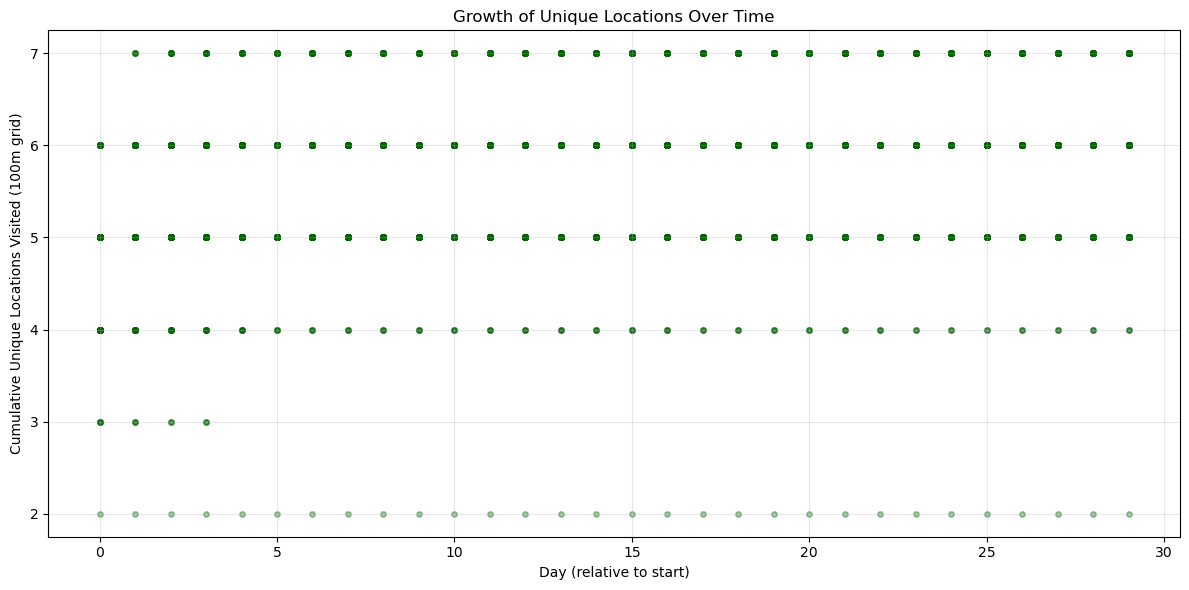

In [53]:
# Create unique location identifier from rounded coordinates (100m grid)
device_df['loc_grid'] = (device_df['x'] // 100).astype(str) + '_' + (device_df['y'] // 100).astype(str)

# Compute cumulative unique locations for each user over time
device_df['day_num'] = (pd.to_datetime(device_df['date']) - pd.to_datetime(device_df['date']).min()).dt.days

cumulative_locations = []
for user_id in device_df['user_id'].unique():
    user_data = device_df[device_df['user_id'] == user_id].sort_values('timestamp')
    for day in range(user_data['day_num'].max() + 1):
        locs_up_to_day = user_data[user_data['day_num'] <= day]['loc_grid'].nunique()
        cumulative_locations.append({'day': day, 'cumulative_locations': locs_up_to_day})

cum_loc_df = pd.DataFrame(cumulative_locations)

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(cum_loc_df['day'], cum_loc_df['cumulative_locations'], alpha=0.2, s=15, color='darkgreen')
ax.set_xlabel('Day (relative to start)')
ax.set_ylabel('Cumulative Unique Locations Visited (100m grid)')
ax.set_title('Growth of Unique Locations Over Time')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()